In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

%matplotlib inline

In [3]:
datos = pd.read_csv(filepath_or_buffer = "/Users/paola/Desktop/DE1_Arbol_Decisión/breast-cancer.csv",sep=',',low_memory=False)

In [4]:
datos

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [5]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
datos.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
datos.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [8]:
print("Datos duplicados:", datos.duplicated().sum())

Datos duplicados: 0


In [9]:
datos["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [10]:
datos = datos.drop(columns=["id"])

In [11]:
datos["diagnosis"] = datos["diagnosis"].map({
    "B": 0,
    "M": 1
})

In [12]:
datos["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [13]:
X = datos.drop(columns=["diagnosis"])
y = datos["diagnosis"]

print("X:", X.shape)
print("y:", y.shape)

X: (569, 30)
y: (569,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (455, 30)
Datos de prueba: (114, 30)


In [16]:
modelo = DecisionTreeClassifier(
    random_state=42
)

In [17]:
modelo.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [18]:
y_pred = modelo.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9298245614035088
Precision: 0.9047619047619048
Recall: 0.9047619047619048
F1-score: 0.9047619047619048


In [20]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benigno", "Maligno"]
    )
)

              precision    recall  f1-score   support

     Benigno       0.94      0.94      0.94        72
     Maligno       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [21]:
matriz = confusion_matrix(y_test, y_pred)

print(matriz)

[[68  4]
 [ 4 38]]


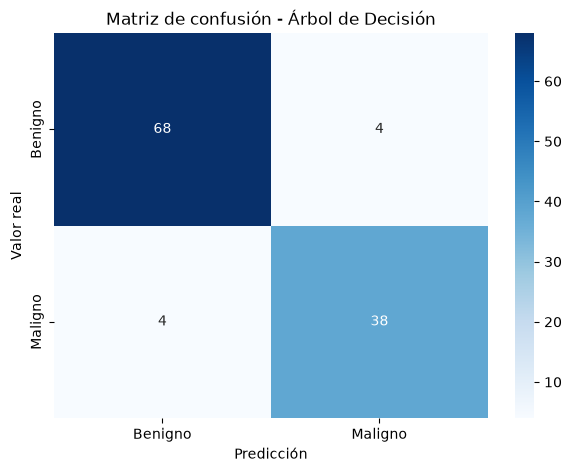

In [22]:
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)

plt.title("Matriz de confusión - Árbol de Decisión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [23]:
print("Profundidad del árbol:", modelo.get_depth())
print("Número de nodos terminales:", modelo.get_n_leaves())

Profundidad del árbol: 8
Número de nodos terminales: 24


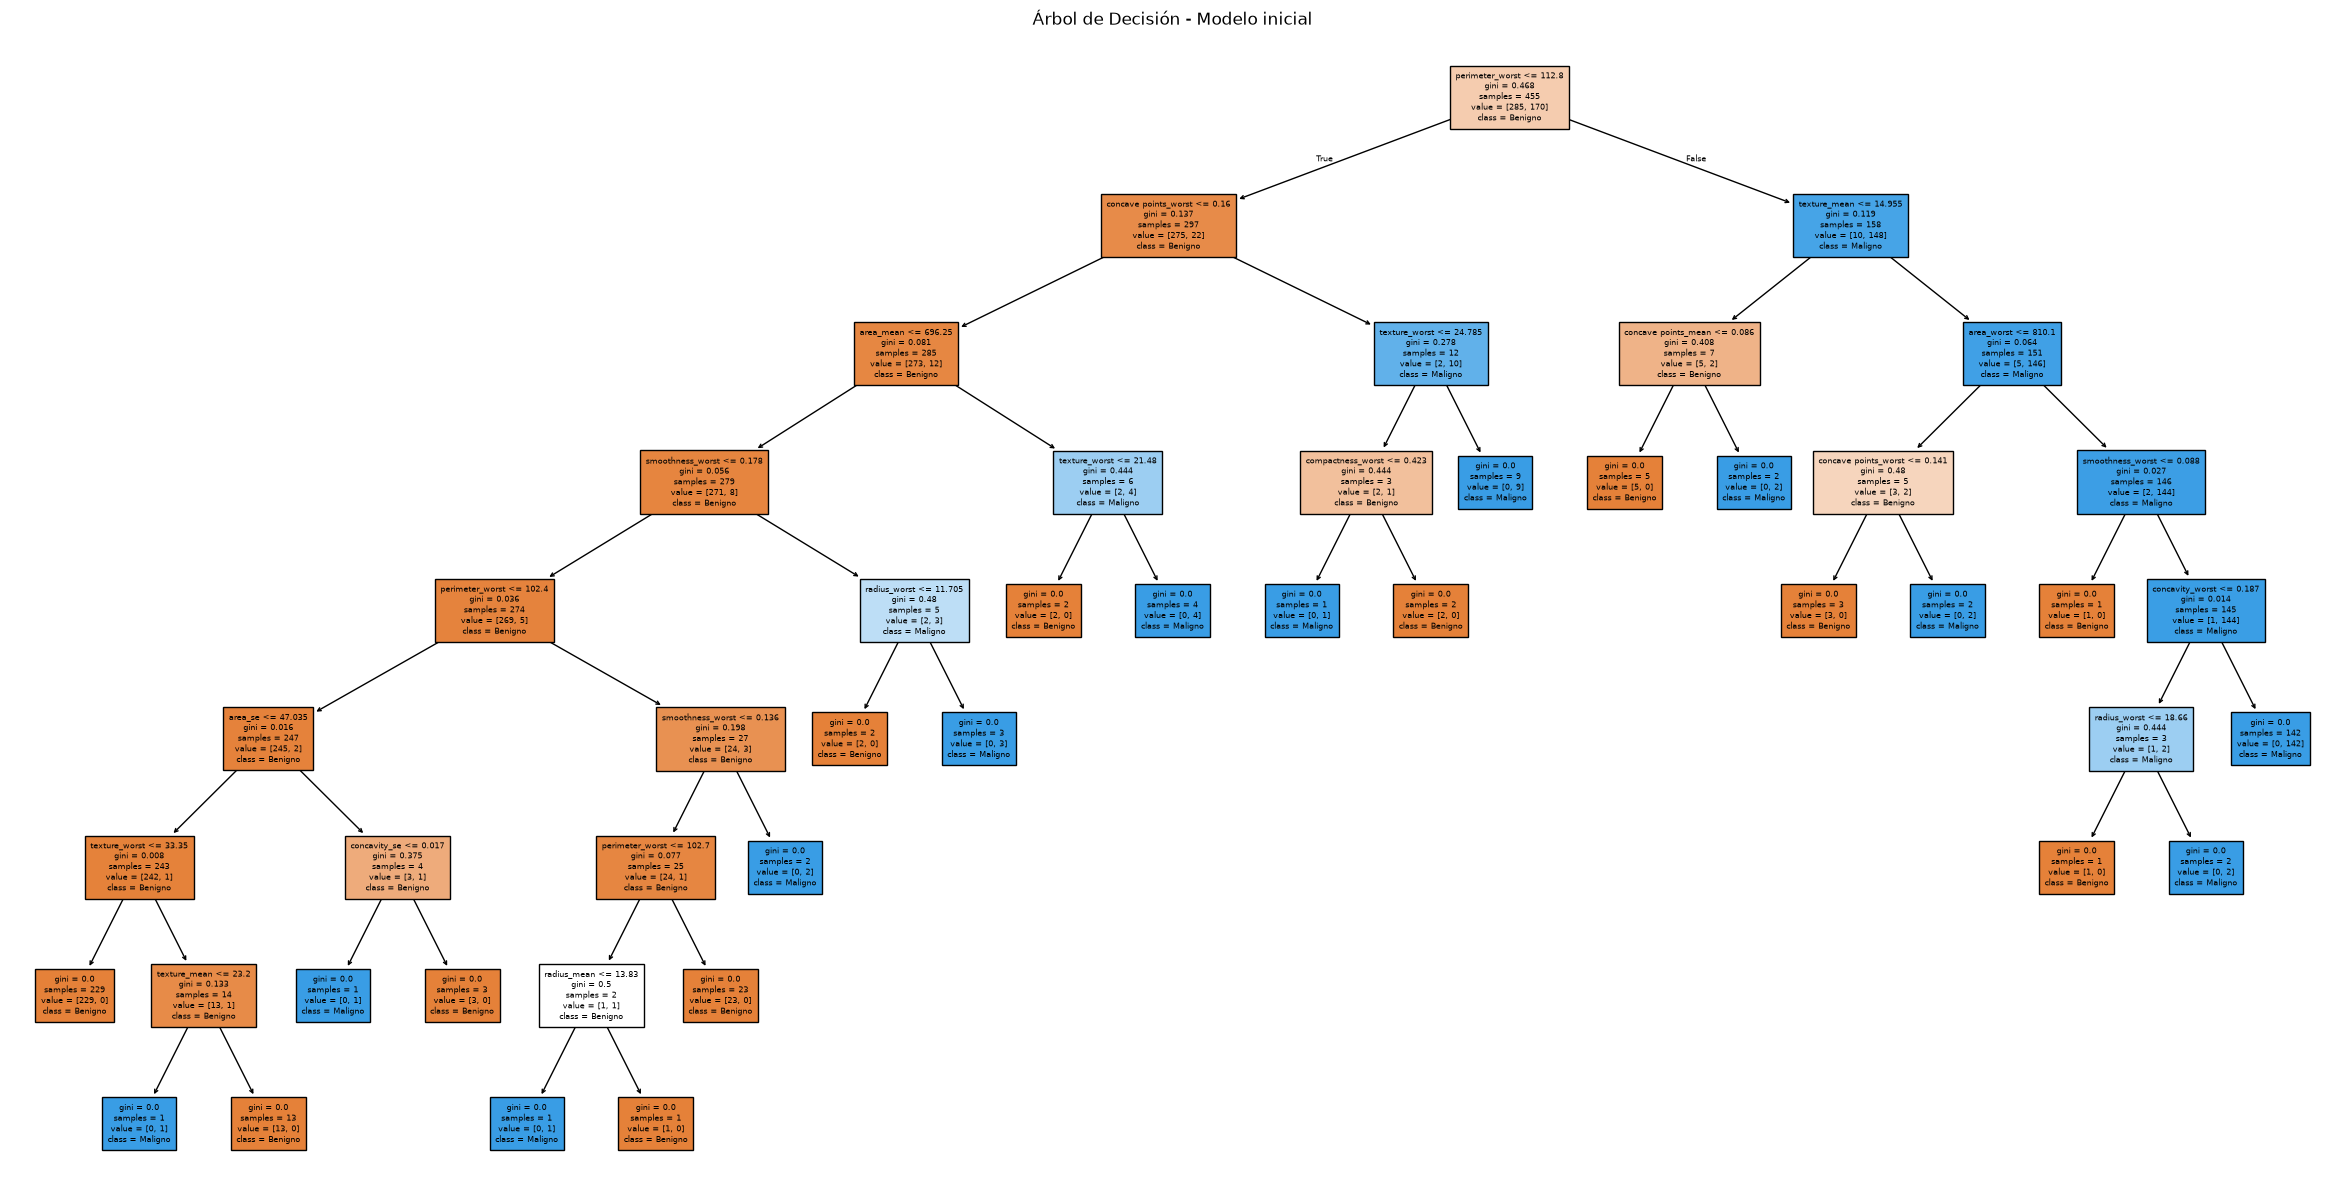

In [24]:
plt.figure(figsize=(30, 15))

plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=["Benigno", "Maligno"],
    filled=True,
    fontsize=6
)

plt.title("Árbol de Decisión - Modelo inicial")
plt.show()

In [25]:
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=1,
    random_state=1
)

In [26]:
parametros = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10, 20]
}

In [27]:
busqueda = GridSearchCV(
    estimator=modelo,
    param_grid=parametros,
    scoring="accuracy",
    n_jobs=1,
    cv=cv
)

In [28]:
resultado = busqueda.fit(
    X_train,
    y_train
)

In [29]:
print("Mejor puntuación:", resultado.best_score_)
print("Mejores hiperparámetros:", resultado.best_params_)

Mejor puntuación: 0.9384615384615385
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}


In [30]:
modelo_optimizado = resultado.best_estimator_

In [31]:
y_pred_opt = modelo_optimizado.predict(X_test)

y_pred_opt

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1])

In [32]:
accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)

print("Accuracy optimizado:", accuracy_opt)
print("Precision optimizado:", precision_opt)
print("Recall optimizado:", recall_opt)
print("F1-score optimizado:", f1_opt)

Accuracy optimizado: 0.9035087719298246
Precision optimizado: 0.918918918918919
Recall optimizado: 0.8095238095238095
F1-score optimizado: 0.8607594936708861


In [33]:
print(
    classification_report(
        y_test,
        y_pred_opt,
        target_names=["Benigno", "Maligno"]
    )
)

              precision    recall  f1-score   support

     Benigno       0.90      0.96      0.93        72
     Maligno       0.92      0.81      0.86        42

    accuracy                           0.90       114
   macro avg       0.91      0.88      0.89       114
weighted avg       0.90      0.90      0.90       114



In [34]:
matriz_opt = confusion_matrix(y_test, y_pred_opt)

print(matriz_opt)

[[69  3]
 [ 8 34]]


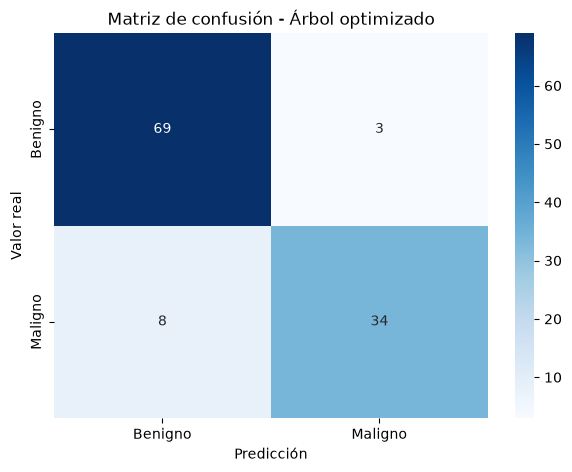

In [35]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_opt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"]
)

plt.title("Matriz de confusión - Árbol optimizado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [36]:
print(
    "Profundidad del árbol optimizado:",
    modelo_optimizado.get_depth()
)

print(
    "Número de hojas del árbol optimizado:",
    modelo_optimizado.get_n_leaves()
)

Profundidad del árbol optimizado: 5
Número de hojas del árbol optimizado: 10


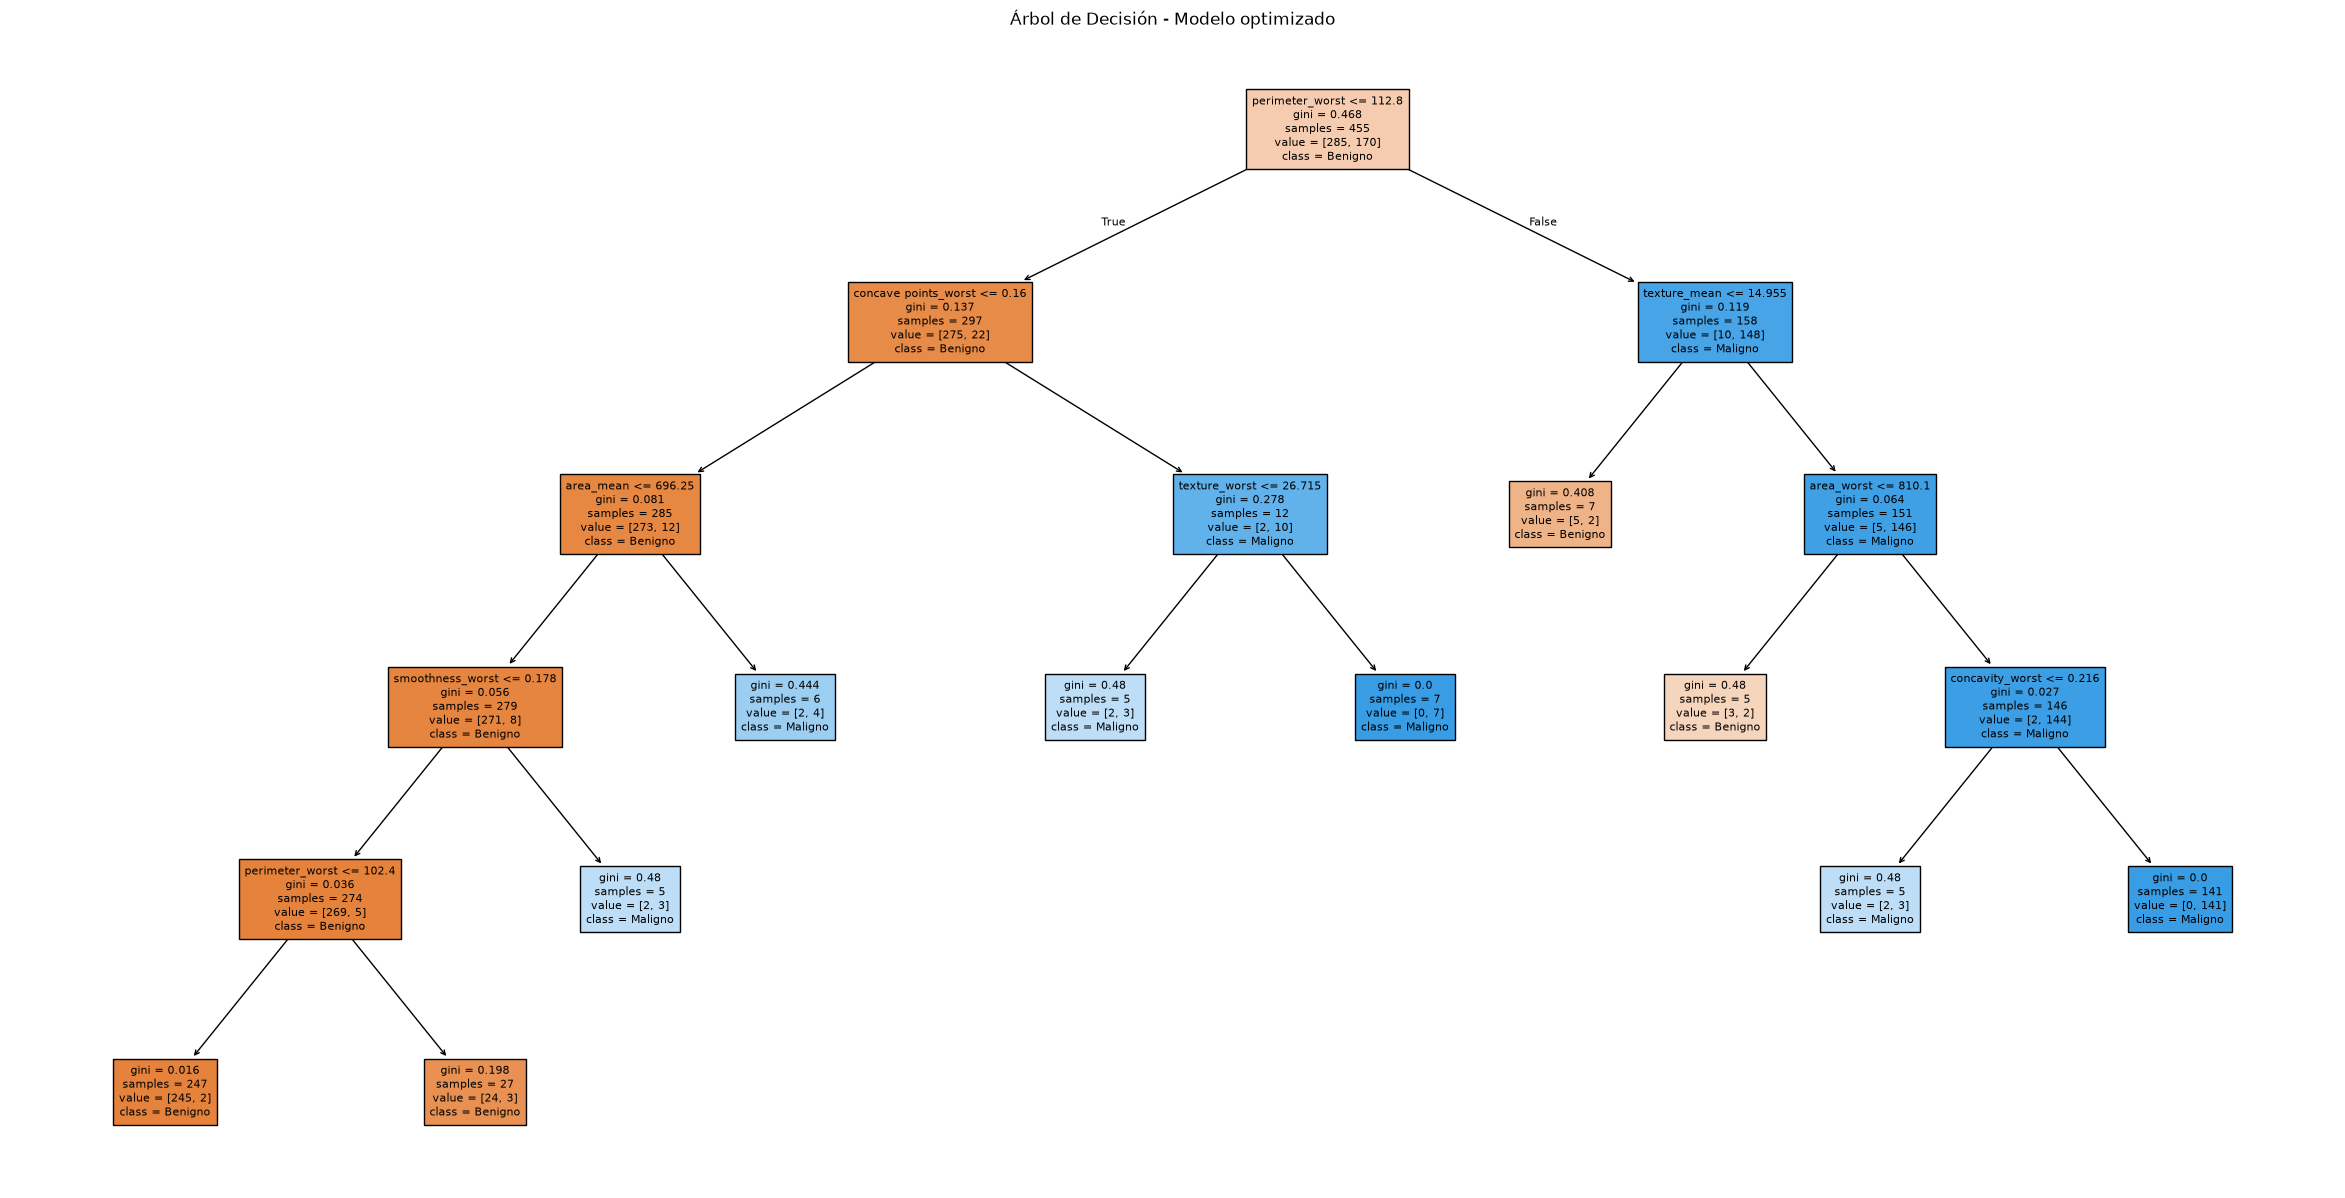

In [37]:
plt.figure(figsize=(30, 15))

plot_tree(
    modelo_optimizado,
    feature_names=X.columns,
    class_names=["Benigno", "Maligno"],
    filled=True,
    fontsize=8
)

plt.title("Árbol de Decisión - Modelo optimizado")

plt.show()

In [38]:
comparacion = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Modelo original": [
        accuracy,
        precision,
        recall,
        f1
    ],
    "Modelo optimizado": [
        accuracy_opt,
        precision_opt,
        recall_opt,
        f1_opt
    ]
})

comparacion

,Métrica,Modelo original,Modelo optimizado
0,Accuracy,0.929825,0.903509
1,Precision,0.904762,0.918919
2,Recall,0.904762,0.809524
3,F1-score,0.904762,0.860759


In [39]:
joblib.dump(
    modelo_optimizado,
    "modelo_arbol_decision_breast_cancer.pkl"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [40]:
modelo_cargado = joblib.load(
    "modelo_arbol_decision_breast_cancer.pkl"
)

predicciones_prueba = modelo_cargado.predict(X_test)

print(predicciones_prueba)

[0 1 1 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 0 1 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 0 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 1 1]
